## Figure 1k-n

## Helper codes: run below cells before any of the other cells. 

In [1]:
from pynwb import NWBHDF5IO
from scipy.io import savemat, loadmat
import mat73
import hdf5storage as st
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, TSNE
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc

from scipy.sparse.linalg import eigsh
from scipy.stats import wilcoxon, kruskal, mannwhitneyu, sem, kstest, pearsonr, spearmanr, gmean
from scipy.optimize import curve_fit
from scipy.ndimage import maximum_filter1d

import seaborn as sns
from copy import deepcopy as dc
from statsmodels.stats.multitest import multipletests
# from statannot import add_stat_annotation

from itertools import combinations, product
import math
from umap import UMAP

# # tell pandas to show all columns when we display a DataFrame
# pd.set_option("display.max_columns", None)

c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ABO Neuropixels
with open('resp_matrix_ep_RS_all_32sess_allensdk.pickle', 'rb') as f:
    resp_matrix_ep_RS_all = pickle.load(f)

    list_rate_RS = resp_matrix_ep_RS_all['list_rate_RS'].copy()
    list_rate_RS_dr = resp_matrix_ep_RS_all['list_rate_RS_dr'].copy()
    list_rate_all = resp_matrix_ep_RS_all['list_rate_all'].copy()
    list_rate_all_dr = resp_matrix_ep_RS_all['list_rate_all_dr'].copy()
    list_slopes_RS_an_loglog = resp_matrix_ep_RS_all['list_slopes_RS_an_loglog'].copy()
    list_slopes_all_att_loglog = resp_matrix_ep_RS_all['list_slopes_all_att_loglog'].copy()
    list_slopes_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_all_an_loglog'].copy()
    list_slopes_stat_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_stat_all_an_loglog'].copy()
    list_slopes_mov_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_mov_all_an_loglog'].copy()

    sess_inds_qual_RS = resp_matrix_ep_RS_all['sess_inds_qual_RS'].copy()
    sess_inds_qual_RS_dr = resp_matrix_ep_RS_all['sess_inds_qual_RS_dr'].copy()
    sess_inds_qual_all = resp_matrix_ep_RS_all['sess_inds_qual_all'].copy()
    sess_inds_qual_all_dr = resp_matrix_ep_RS_all['sess_inds_qual_all_dr'].copy()
    
# ABO Neuropixels behavior
with open('resp_matrix_ep_bhv_all_32sess_gpu.pickle', 'rb') as f:
    resp_matrix_ep_RS_all = pickle.load(f)

    list_rate_all_act = resp_matrix_ep_RS_all['list_rate_all_act'].copy()
    list_rate_all_pas = resp_matrix_ep_RS_all['list_rate_all_pas'].copy()
    list_slopes_all_att_loglog_act = resp_matrix_ep_RS_all['list_slopes_all_att_loglog_act'].copy()
    list_slopes_all_an_loglog_act = resp_matrix_ep_RS_all['list_slopes_all_an_loglog_act'].copy()
    list_slopes_all_att_loglog_pas = resp_matrix_ep_RS_all['list_slopes_all_att_loglog_pas'].copy()
    list_slopes_all_an_loglog_pas = resp_matrix_ep_RS_all['list_slopes_all_an_loglog_pas'].copy()
    bool_sess_excl = resp_matrix_ep_RS_all['bool_sess_excl'].copy()
    bool_G = resp_matrix_ep_RS_all['bool_G'].copy()
    bool_H = resp_matrix_ep_RS_all['bool_H'].copy()
    bool_fam = resp_matrix_ep_RS_all['bool_fam'].copy()
    bool_nov = resp_matrix_ep_RS_all['bool_nov'].copy()
    list_sess_ids = resp_matrix_ep_RS_all['list_sess_ids'].copy()
    list_neuallloc = resp_matrix_ep_RS_all['list_neuallloc'].copy()
    list_sess_visp = resp_matrix_ep_RS_all['list_sess_visp'].copy()

In [4]:
def compute_mean_var_trial(label_cnt_dict, rate_sorted):    
    list_trial_mean = [[0]] * len(label_cnt_dict)
    list_trial_var = [[0]] * len(label_cnt_dict)

    for trial_ind, trial_type in enumerate(label_cnt_dict):
        
        trial_rate = np.array(rate_sorted.loc[:, trial_type])                
        trial_mean = np.mean(trial_rate, axis=1)
        trial_var = np.var(trial_rate, axis=1, ddof=1)

        trial_mean = pd.DataFrame(trial_mean, columns=[trial_type], index=rate_sorted.index)
        trial_var = pd.DataFrame(trial_var, columns=[trial_type], index=rate_sorted.index)
        list_trial_mean[trial_ind] = pd.concat([trial_mean] * label_cnt_dict[trial_type], axis=1)
        list_trial_var[trial_ind] = pd.concat([trial_var] * label_cnt_dict[trial_type], axis=1)

    rate_sorted_mean = pd.concat(list_trial_mean, axis=1)
    rate_sorted_var = pd.concat(list_trial_var, axis=1)

    return rate_sorted_mean, rate_sorted_var

In [5]:
def compute_mean_var_trial_collapse(label_cnt_dict, rate_sorted):    
    list_trial_mean = [[0]] * len(label_cnt_dict)
    list_trial_var = [[0]] * len(label_cnt_dict)

    for trial_ind, trial_type in enumerate(label_cnt_dict):
        
        trial_rate = np.array(rate_sorted.loc[:, trial_type])                
        trial_mean = np.mean(trial_rate, axis=1, dtype=np.longdouble)
        trial_var = np.var(trial_rate, axis=1, ddof=1, dtype=np.longdouble)

        trial_mean = pd.DataFrame(trial_mean, columns=[trial_type], index=rate_sorted.index)
        trial_var = pd.DataFrame(trial_var, columns=[trial_type], index=rate_sorted.index)
        list_trial_mean[trial_ind] = trial_mean.copy()
        list_trial_var[trial_ind] = trial_var.copy()

    rate_sorted_mean = pd.concat(list_trial_mean, axis=1)
    rate_sorted_var = pd.concat(list_trial_var, axis=1)

    return rate_sorted_mean, rate_sorted_var

In [6]:
def annotate_lineplot_significance(significant_values, axes, ax_ind, line_height_ratio, color):

    if len(significant_values) > 0:

        # Initialize start and end points of lines
        start = None
        lines = []
        dots = []

        # Loop through sorted significant_values to group them into lines or dots
        for i in range(len(significant_values) - 1):
            if start is None:
                start = significant_values[i]

            # Check if the next value is part of the same line
            if significant_values[i + 1] - significant_values[i] > 0.1 + 1e-9:  # Threshold for a gap; add pseudo-value to avoid floating point issue
                if start == significant_values[i]:
                    dots.append(start)  # Isolated point
                else:
                    lines.append((start, significant_values[i]))  # Line segment
                start = None

        # Check the last value
        if start is None:
            dots.append(significant_values[-1])
        else:
            lines.append((start, significant_values[-1]))

        # Plot lines and dots
        for line in lines:
            if isinstance(axes, np.ndarray):
                axes[ax_ind].hlines(axes[ax_ind].get_ylim()[0]+(axes[ax_ind].get_ylim()[1]-axes[ax_ind].get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)  # Draw a line
            elif isinstance(axes, plt.Axes):
                axes.hlines(axes.get_ylim()[0]+(axes.get_ylim()[1]-axes.get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)
            else:
                plt.hlines(plt.gca().get_ylim()[0]+(plt.gca().get_ylim()[1]-plt.gca().get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)
                
        for dot in dots:
            if isinstance(axes, np.ndarray):
                axes[ax_ind].hlines(axes[ax_ind].get_ylim()[0]+(axes[ax_ind].get_ylim()[1]-axes[ax_ind].get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)  # Draw a very short line
            elif isinstance(axes, plt.Axes):
                axes.hlines(axes.get_ylim()[0]+(axes.get_ylim()[1]-axes.get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)
            else:
                plt.hlines(plt.gca().get_ylim()[0]+(plt.gca().get_ylim()[1]-plt.gca().get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)

In [7]:
def get_upper_whisker(data, whis=1.5):
    """Calculates the top of the upper whisker (ignoring hidden outliers)."""
    data = np.array(data)
    q1 = np.nanpercentile(data, 25)
    q3 = np.nanpercentile(data, 75)
    iqr = q3 - q1
    upper_bound = q3 + whis * iqr
    valid_points = data[data <= upper_bound]
    
    return np.nanmax(valid_points) if len(valid_points) > 0 else np.nanmax(data)

def add_significance_bars(ax, comparisons, y_max_values, x_positions=None, p_values=None, 
                          gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1, fontsize=10, ignore_ns=True):

    if p_values is None: p_values = ['*' for _ in comparisons]
    if x_positions is None: x_positions = np.arange(len(y_max_values))
    if ignore_ns:
        pval_thres = 0.05
    else:
        pval_thres = 1
    
    # Sort Comparisons: Distance first, then height
    def sort_key(item):
        (idx1, idx2), _ = item
        x_min, x_max = min(idx1, idx2), max(idx1, idx2)
        dist = x_max - x_min
        height = max(y_max_values[x_min : x_max + 1])
        return (dist, height)

    combined = list(zip(comparisons, p_values))
    combined.sort(key=sort_key)
    sorted_comparisons, sorted_p_values = zip(*combined)
    
    # Scale Factors
    y_min, y_max = np.nanmin(y_max_values), np.nanmax(y_max_values)
    y_range = y_max - y_min if y_max != y_min else 1.0

    # Get physical figure size in inches
    fig = ax.get_figure()
    fig_height_inch = fig.get_figheight()
    
    # Get axis height in fraction of figure (e.g., 0.8)
    bbox = ax.get_position()
    ax_height_inch = fig_height_inch * bbox.height

    # Get current Y-axis range (data units)
    y_min, y_max = ax.get_ylim()
    y_range_real = y_max - y_min

    # Conversion: (Points / 72 inch/pt) * (Data Range / Axis Height inches)
    text_height_data = (fontsize / 72) * (y_range_real / ax_height_inch)
    
    # Define gaps relative to the text size
    clearance = text_height_data * gap_below_line
    text_height = text_height_data
    
    # Initialize Interval Skyline
    # If we have N columns, we have N-1 gaps.
    n_columns = len(y_max_values)
    interval_skyline = [0] * (n_columns - 1)
    
    # Draw Bars
    for com_ind, ((idx1, idx2), pval) in enumerate(zip(sorted_comparisons, sorted_p_values)):
        if pval <= pval_thres:
            x1, x2 = min(idx1, idx2), max(idx1, idx2)
            
            # Check Data Height
            data_peak = np.nanmax(y_max_values[x1 : x2 + 1])
            
            # Check Interval Height
            if x1 < x2:
                interval_peak = np.nanmax(interval_skyline[x1:x2]) if interval_skyline[x1:x2] else 0
            else:
                interval_peak = 0
                
            # Determine drawing height
            # Must clear both the data and the previous bars below it
            y_line = np.nanmax([data_peak, interval_peak]) + clearance
            
            # if adjacent bars have same height, move up the second one
            if com_ind >= 1:
                idx1_prev, idx2_prev = sorted_comparisons[com_ind-1]
                x1_prev, x2_prev = min(idx1_prev, idx2_prev), max(idx1_prev, idx2_prev)
                pval_prev = sorted_p_values[com_ind-1]
                if x2 - x1 == 1 and x2_prev - x1_prev == 1 and x1 == x2_prev and pval_prev <= pval_thres:
                    y_line_prev = interval_skyline[x1_prev] - text_height
                    if np.isclose(y_line, y_line_prev):
                        y_line += clearance * bottomline_offset

            # Draw Line
            x_pos1, x_pos2 = x_positions[x1], x_positions[x2]
            line_x = [x_pos1, x_pos2]
            line_y = [y_line, y_line]
            ax.plot(line_x, line_y, lw=1.5, c='k')
        
            # Add Text
            text_y = y_line + (clearance * gap_below_text)
            if pval < 0.001:
                asterisk = '***'
            elif pval < 0.01:
                asterisk = '**'
            elif pval < 0.05:
                asterisk = '*'
            else:
                asterisk = f'p={pval:.2f}'
            ax.text((x_pos1 + x_pos2) * 0.5, text_y, asterisk, ha='center', va='bottom', color='k')
            
            # Update Interval Skyline
            new_height = y_line + text_height
            for k in range(x1, x2):
                interval_skyline[k] = new_height

    return ax

In [8]:
# # matlab reponse matrix (spike rate) loading
# num_sess = len(list_sess_ids)
# list_rate_all_act = np.empty(num_sess, dtype=object)
# list_rate_all_pas = np.empty(num_sess, dtype=object)
# list_neuallloc = np.empty(num_sess, dtype=object)
# for sess_ind, sess_id in enumerate(list_sess_ids):
#     # if sess_ind == 0:
#         print(f'sess_ind {sess_ind}')
#         file_path = 'D:\\Users\\USER\\MATLAB\\ABCD_ephys\\' + str(sess_id) + '\\postprocessed.mat'
#         pp = loadmat(file_path, simplify_cells=True)
#         Rall = pp['Rall'].copy()
#         vis = pp['vis'].copy()
#         ns_key = np.array(list(pp['Rall'].keys()))[[('Natural_Images' in key) for key in pp['Rall'].keys()]][0] # G or H
#         # print(ns_key)
        
#         # convert column names into integers
#         image_name = vis[ns_key]['image_name'].copy() # image for each trial
#         bool_omit = image_name == 'omitted'
#         for trial_ind, name in enumerate(image_name):
#             if trial_ind in np.where(bool_omit)[0]:
#                 image_name[trial_ind] = -1
#             else:
#                 image_name[trial_ind] = int(name[2:].split('_')[0])
#         rate = pd.DataFrame(Rall[ns_key], columns=image_name)

#         # divide active vs. passive blocks
#         bool_active = vis[ns_key]['active'].astype(bool)
#         # print(np.sum(bool_active))
#         rate_act = rate.loc[:, bool_active].copy()
#         rate_pas = rate.loc[:, ~bool_active].copy()
#         list_rate_all_act[sess_ind] = rate_act.copy()
#         list_rate_all_pas[sess_ind] = rate_pas.copy()

#         # brain area for each neuron
#         list_neuallloc[sess_ind] = pp['neuallloc'].copy()

In [9]:
# # 'train G, record H -> G' sessions
# print(ecephys_sessions_table.columns)
# bool_sess_excl = ((ecephys_sessions_table['session_number'] == 1) & (ecephys_sessions_table['experience_level'] == 'Novel'))\
# | ((ecephys_sessions_table['session_number'] == 2) & (ecephys_sessions_table['experience_level'] == 'Familiar'))
# print(np.sum(bool_sess_excl))

# # image set G vs. H boolean index
# bool_G = ecephys_sessions_table['image_set'] == 'G'
# bool_H = ecephys_sessions_table['image_set'] == 'H'

# # familiar vs. novel boolean index
# bool_fam = ecephys_sessions_table['experience_level'] == 'Familiar'
# bool_nov = ecephys_sessions_table['experience_level'] == 'Novel'

In [10]:
# # session index with V1 units
# num_sess = len(list_sess_ids)
# list_sess_visp = np.zeros(num_sess, dtype=bool)
# for sess_ind, (rate_all, neu_loc) in enumerate(zip(list_rate_all_act, list_neuallloc)):
#     # print(f'session index: {sess_ind}')

#     # extract V1 neurons
#     ser_neu_loc = pd.Series(neu_loc)
#     list_visp = [ser_neu_loc.str.contains('VISp'), ~ser_neu_loc.str.contains('VISpm')]
#     rate = rate_all[[all(bools) for bools in zip(*list_visp)]].copy()
#     if rate.shape[0] > 0: # if neurons exist
#         list_sess_visp[sess_ind] = True
# print(list_sess_visp)

## Codes for figures

## Figure 1k, l

In [11]:
# # Linear Fitting Slope across stimuli (all neurons) (loglog line) (active block)

# # Iterate over all sessions
# num_sess = len(list_sess_ids)
# list_slopes_all_att_loglog_act = np.empty(num_sess, dtype=object)
# for sess_ind, (rate_all, neu_loc) in enumerate(zip(list_rate_all_act, list_neuallloc)):
#     print(f'session index: {sess_ind}')

#     # extract V1 neurons
#     ser_neu_loc = pd.Series(neu_loc)
#     list_visp = [ser_neu_loc.str.contains('VISp'), ~ser_neu_loc.str.contains('VISpm')]
#     rate = rate_all[[all(bools) for bools in zip(*list_visp)]].copy()
#     if rate.shape[0] > 0: # if neurons exist
#         # remove familiar images in novel sessions
#         if bool_nov.iloc[sess_ind]:
#             rate = rate.drop(columns=[83, 111])
#             # print(np.unique(rate.columns))

#         rate_sorted = rate.sort_index(axis=1)
#         stm = rate_sorted.columns.copy()

#         # Multiply by delta t to convert to spike counts
#         rate_sorted = rate_sorted * 0.25

#         # Create a counting dictionary for each stimulus
#         all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#         stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#         # Compute mean & variance for each stimulus
#         rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate_sorted)
#         rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate_sorted)

#         # Calculate and collect linear slopes for all neurons
#         slopes = np.full((2, rate_sorted_mean_coll.shape[0]), np.nan)
#         for ind, neu_ind in enumerate(rate_sorted_mean_coll.index):

#             # loglog scale
#             bool_mean_notzero = rate_sorted_mean_coll.loc[neu_ind] > 0
#             if np.any(bool_mean_notzero):
#                     popt = np.polyfit(np.log10(rate_sorted_mean.loc[neu_ind, bool_mean_notzero].values).flatten().astype(np.float32), \
#                                     np.log10(rate_sorted_var.loc[neu_ind, bool_mean_notzero].values).flatten().astype(np.float32), 1)
#                     # popt = np.polyfit(np.log10(rate_sorted_mean.loc[:, trial_type].values).flatten().astype(np.float32), \
#                     #                      np.log10(rate_sorted_var.loc[:, trial_type].values).flatten().astype(np.float32), 1)
                    
#                     slopes[:, ind] = popt.copy()
        
#         list_slopes_all_att_loglog_act[sess_ind] = slopes.copy()

In [12]:
# # Linear Fitting Slope across neurons (all neurons) (loglog line) (active block)

# # Iterate over all sessions
# num_sess = len(list_sess_ids)
# list_slopes_all_an_loglog_act = np.empty(num_sess, dtype=object)
# for sess_ind, (rate_all, neu_loc) in enumerate(zip(list_rate_all_act, list_neuallloc)):
#     print(f'session index: {sess_ind}')

#     # extract V1 neurons
#     ser_neu_loc = pd.Series(neu_loc)
#     list_visp = [ser_neu_loc.str.contains('VISp'), ~ser_neu_loc.str.contains('VISpm')]
#     rate = rate_all[[all(bools) for bools in zip(*list_visp)]].copy()
#     if rate.shape[0] > 0: # if neurons exist
#         # remove familiar images in novel sessions
#         if bool_nov.iloc[sess_ind]:
#             rate = rate.drop(columns=[83, 111])
#             # print(np.unique(rate.columns))
        
#         rate_sorted = rate.sort_index(axis=1)
#         stm = rate_sorted.columns.copy()

#         # Multiply by delta t to convert to spike counts
#         rate_sorted = rate_sorted * 0.25

#         # Create a counting dictionary for each stimulus
#         all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#         stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#         # Compute mean & variance for each stimulus
#         rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate_sorted)
#         rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate_sorted)

#         # Calculate and collect linear slopes for all stimuli
#         slopes = np.zeros((2, rate_sorted_mean_coll.shape[1]))
#         for trial_type_ind, trial_type in enumerate(rate_sorted_mean_coll.columns):

#             # loglog scale
#             bool_mean_notzero = rate_sorted_mean_coll.loc[:, trial_type] > 0
#             popt = np.polyfit(np.log10(rate_sorted_mean.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), \
#                                 np.log10(rate_sorted_var.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), 1)
#             # popt = np.polyfit(np.log10(rate_sorted_mean.loc[:, trial_type].values).flatten().astype(np.float32), \
#             #                      np.log10(rate_sorted_var.loc[:, trial_type].values).flatten().astype(np.float32), 1)
            
#             slopes[:, trial_type_ind] = popt.copy()
        
#         list_slopes_all_an_loglog_act[sess_ind] = slopes.copy()

In [13]:
# # Linear Fitting Slope across stimuli (all neurons) (loglog line) (passive block)

# # Iterate over all sessions
# num_sess = len(list_sess_ids)
# list_slopes_all_att_loglog_pas = np.empty(num_sess, dtype=object)
# for sess_ind, (rate_all, neu_loc) in enumerate(zip(list_rate_all_pas, list_neuallloc)):
#     print(f'session index: {sess_ind}')

#     # extract V1 neurons
#     ser_neu_loc = pd.Series(neu_loc)
#     list_visp = [ser_neu_loc.str.contains('VISp'), ~ser_neu_loc.str.contains('VISpm')]
#     rate = rate_all[[all(bools) for bools in zip(*list_visp)]].copy()
#     if rate.shape[0] > 0: # if neurons exist
#         # remove familiar images in novel sessions
#         if bool_nov.iloc[sess_ind]:
#             rate = rate.drop(columns=[83, 111])
#             # print(np.unique(rate.columns))

#         rate_sorted = rate.sort_index(axis=1)
#         stm = rate_sorted.columns.copy()

#         # Multiply by delta t to convert to spike counts
#         rate_sorted = rate_sorted * 0.25
        
#         # Create a counting dictionary for each stimulus
#         all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#         stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#         # Compute mean & variance for each stimulus
#         rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate_sorted)
#         rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate_sorted)

#         # Calculate and collect linear slopes for all neurons
#         slopes = np.full((2, rate_sorted_mean_coll.shape[0]), np.nan)
#         for ind, neu_ind in enumerate(rate_sorted_mean_coll.index):

#             # loglog scale
#             bool_mean_notzero = rate_sorted_mean_coll.loc[neu_ind] > 0
#             if np.any(bool_mean_notzero):
#                 popt = np.polyfit(np.log10(rate_sorted_mean.loc[neu_ind, bool_mean_notzero].values).flatten().astype(np.float32), \
#                                     np.log10(rate_sorted_var.loc[neu_ind, bool_mean_notzero].values).flatten().astype(np.float32), 1)
#                 # popt = np.polyfit(np.log10(rate_sorted_mean.loc[:, trial_type].values).flatten().astype(np.float32), \
#                 #                      np.log10(rate_sorted_var.loc[:, trial_type].values).flatten().astype(np.float32), 1)
                
#                 slopes[:, ind] = popt.copy()
        
#         list_slopes_all_att_loglog_pas[sess_ind] = slopes.copy()

In [14]:
# # Linear Fitting Slope across neurons (all neurons) (loglog line) (passive block)

# # Iterate over all sessions
# num_sess = len(list_sess_ids)
# list_slopes_all_an_loglog_pas = np.empty(num_sess, dtype=object)
# for sess_ind, (rate_all, neu_loc) in enumerate(zip(list_rate_all_pas, list_neuallloc)):
#     print(f'session index: {sess_ind}')

#     # extract V1 neurons
#     ser_neu_loc = pd.Series(neu_loc)
#     list_visp = [ser_neu_loc.str.contains('VISp'), ~ser_neu_loc.str.contains('VISpm')]
#     rate = rate_all[[all(bools) for bools in zip(*list_visp)]].copy()
#     if rate.shape[0] > 0: # if neurons exist
#         # remove familiar images in novel sessions
#         if bool_nov.iloc[sess_ind]:
#             rate = rate.drop(columns=[83, 111])
#             # print(np.unique(rate.columns))

#         rate_sorted = rate.sort_index(axis=1)
#         stm = rate_sorted.columns.copy()

#         # Multiply by delta t to convert to spike counts
#         rate_sorted = rate_sorted * 0.25
        
#         # Create a counting dictionary for each stimulus
#         all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#         stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#         # Compute mean & variance for each stimulus
#         rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate_sorted)
#         rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate_sorted)

#         # Calculate and collect linear slopes for all stimuli
#         slopes = np.zeros((2, rate_sorted_mean_coll.shape[1]))
#         for trial_type_ind, trial_type in enumerate(rate_sorted_mean_coll.columns):

#             # loglog scale
#             bool_mean_notzero = rate_sorted_mean_coll.loc[:, trial_type] > 0
#             popt = np.polyfit(np.log10(rate_sorted_mean.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), \
#                                 np.log10(rate_sorted_var.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), 1)
#             # popt = np.polyfit(np.log10(rate_sorted_mean.loc[:, trial_type].values).flatten().astype(np.float32), \
#             #                      np.log10(rate_sorted_var.loc[:, trial_type].values).flatten().astype(np.float32), 1)
            
#             slopes[:, trial_type_ind] = popt.copy()
        
#         list_slopes_all_an_loglog_pas[sess_ind] = slopes.copy()

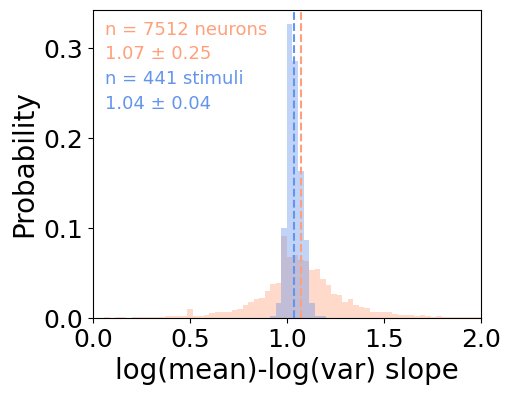

1.0608235536657658
Across stimuli slope mean 1.07, SEM 0.0029, std 0.25
1.0326007278026992
Across neurons slope mean 1.04, SEM 0.0017, std 0.04


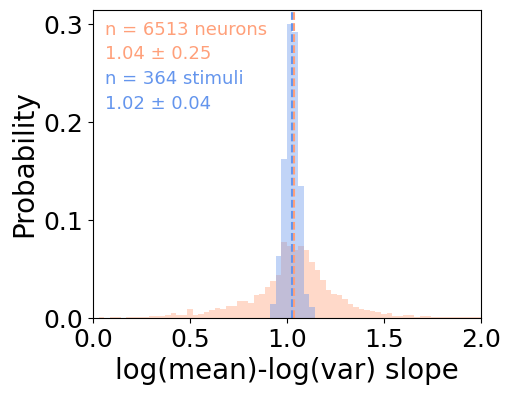

1.0445892136454251
Across stimuli slope mean 1.04, SEM 0.0032, std 0.25
1.0252688562968553
Across neurons slope mean 1.02, SEM 0.0019, std 0.04


In [15]:
# slope across neurons (familiar vs. novel) (active block)

list_slopes_all_att_loglog_act_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_att_loglog_act) if sess_ind in np.where(~bool_sess_excl)[0] and slopes is not None])
list_slopes_all_an_loglog_act_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_act) if sess_ind in np.where(~bool_sess_excl)[0] and slopes is not None])

# bool_fam2 = ~bool_sess_excl & bool_fam
# bool_nov2 = ~bool_sess_excl & bool_nov
bool_fam2 = bool_fam
bool_nov2 = bool_nov
list_slopes_all_att_loglog_act_fam = list_slopes_all_att_loglog_act[bool_fam2].copy()
list_slopes_all_att_loglog_act_nov = list_slopes_all_att_loglog_act[bool_nov2].copy()
list_slopes_all_an_loglog_act_fam = list_slopes_all_an_loglog_act[bool_fam2].copy()
list_slopes_all_an_loglog_act_nov = list_slopes_all_an_loglog_act[bool_nov2].copy()

# 1. familiar
fig, ax = plt.subplots(figsize=(5, 4))

list_slopes_all_att_loglog_act_fam_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_att_loglog_act_fam) if slopes is not None])
lower_bound, upper_bound = 0, 2
n_bins = 70
weights = np.ones_like(list_slopes_all_att_loglog_act_fam_flattened)
weights = np.ones_like(list_slopes_all_att_loglog_act_fam_flattened) / len(list_slopes_all_att_loglog_act_fam_flattened)
ax.hist(list_slopes_all_att_loglog_act_fam_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='lightsalmon', alpha=0.4, label='LMLV$_{neuron}$')
ax.axvline(np.nanmean(list_slopes_all_att_loglog_act_fam_flattened), color='lightsalmon', linestyle='--')

list_slopes_all_an_loglog_act_fam_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_act_fam) if slopes is not None])
lower_bound, upper_bound = 0, 2
n_bins = 70
weights = np.ones_like(list_slopes_all_an_loglog_act_fam_flattened)
weights = np.ones_like(list_slopes_all_an_loglog_act_fam_flattened) / len(list_slopes_all_an_loglog_act_fam_flattened)
ax.hist(list_slopes_all_an_loglog_act_fam_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='cornflowerblue', alpha=0.4, label='LMLV$_{stim}$')
ax.axvline(np.nanmean(list_slopes_all_an_loglog_act_fam_flattened), color='cornflowerblue', linestyle='--')

# ax.set_title(f'Active familiar', fontsize=20)
ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
ax.set_ylabel('Probability', fontsize=20)
# ax.set_xticks([0, 0.5, 1, 1.5, 2])
# ax.set_yticks([100, 300, 500, 700])
ax.tick_params('both', labelsize=18)

ax.set_xlim(0, 2)
# ax.set_ylim(0, 0.35)
# ax.legend(loc='upper left', prop={'size': 14})
ax.annotate(f'n = {list_slopes_all_att_loglog_act_fam_flattened.shape[0]} neurons', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=13, color='lightsalmon')
# ax.annotate(f'{np.nanmean(list_slopes_all_att_loglog_act_fam_flattened):.3f} ± {sem(list_slopes_all_att_loglog_act_fam_flattened, nan_policy="omit"):.3f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'{np.nanmean(list_slopes_all_att_loglog_act_fam_flattened):.2f} ± {np.nanstd(list_slopes_all_att_loglog_act_fam_flattened, ddof=1):.2f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'n = {list_slopes_all_an_loglog_act_fam_flattened.shape[0]} stimuli', xy=(0.03, 0.76), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
# ax.annotate(f'{np.mean(list_slopes_all_an_loglog_act_fam_flattened):.3f} ± {sem(list_slopes_all_an_loglog_act_fam_flattened):.3f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
ax.annotate(f'{np.mean(list_slopes_all_an_loglog_act_fam_flattened):.2f} ± {np.std(list_slopes_all_an_loglog_act_fam_flattened, ddof=1):.2f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')

# plt.savefig('code_images\\svg\\ABCD_slope_histogram_actfam_2cond.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\ABCD_slope_histogram_actfam_2cond.png', dpi=300, bbox_inches='tight')
plt.show()

# print
print(np.nanmedian(list_slopes_all_att_loglog_act_fam_flattened))
print(f'Across stimuli slope mean {np.nanmean(list_slopes_all_att_loglog_act_fam_flattened):.2f}, SEM {sem(list_slopes_all_att_loglog_act_fam_flattened, nan_policy="omit"):.4f}, \
std {np.nanstd(list_slopes_all_att_loglog_act_fam_flattened, ddof=1):.2f}')

print(np.median(list_slopes_all_an_loglog_act_fam_flattened))
print(f'Across neurons slope mean {np.nanmean(list_slopes_all_an_loglog_act_fam_flattened):.2f}, SEM {sem(list_slopes_all_an_loglog_act_fam_flattened, nan_policy="omit"):.4f}, \
std {np.nanstd(list_slopes_all_an_loglog_act_fam_flattened, ddof=1):.2f}')

# 2. novel
fig, ax = plt.subplots(figsize=(5, 4))

list_slopes_all_att_loglog_act_nov_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_att_loglog_act_nov) if slopes is not None])
lower_bound, upper_bound = 0, 2
n_bins = 70
weights = np.ones_like(list_slopes_all_att_loglog_act_nov_flattened)
weights = np.ones_like(list_slopes_all_att_loglog_act_nov_flattened) / len(list_slopes_all_att_loglog_act_nov_flattened)
ax.hist(list_slopes_all_att_loglog_act_nov_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='lightsalmon', alpha=0.4, label='LMLV$_{neuron}$')
ax.axvline(np.nanmean(list_slopes_all_att_loglog_act_nov_flattened), color='lightsalmon', linestyle='--')

list_slopes_all_an_loglog_act_nov_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_act_nov) if slopes is not None])
lower_bound, upper_bound = 0, 2
n_bins = 70
weights = np.ones_like(list_slopes_all_an_loglog_act_nov_flattened)
weights = np.ones_like(list_slopes_all_an_loglog_act_nov_flattened) / len(list_slopes_all_an_loglog_act_nov_flattened)
ax.hist(list_slopes_all_an_loglog_act_nov_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='cornflowerblue', alpha=0.4, label='LMLV$_{stim}$')
ax.axvline(np.nanmean(list_slopes_all_an_loglog_act_nov_flattened), color='cornflowerblue', linestyle='--')

# ax.set_title(f'Active novel', fontsize=20)
ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
ax.set_ylabel('Probability', fontsize=20)
# ax.set_xticks([0, 0.5, 1, 1.5, 2])
# ax.set_yticks([100, 300, 500, 700])
ax.tick_params('both', labelsize=18)

ax.set_xlim(0, 2)
# ax.set_ylim(0, 0.35)
# ax.legend(loc='upper left', prop={'size': 14})
ax.annotate(f'n = {list_slopes_all_att_loglog_act_nov_flattened.shape[0]} neurons', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=13, color='lightsalmon')
# ax.annotate(f'{np.nanmean(list_slopes_all_att_loglog_act_nov_flattened):.3f} ± {sem(list_slopes_all_att_loglog_act_nov_flattened, nan_policy="omit"):.3f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'{np.nanmean(list_slopes_all_att_loglog_act_nov_flattened):.2f} ± {np.nanstd(list_slopes_all_att_loglog_act_nov_flattened, ddof=1):.2f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'n = {list_slopes_all_an_loglog_act_nov_flattened.shape[0]} stimuli', xy=(0.03, 0.76), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
# ax.annotate(f'{np.mean(list_slopes_all_an_loglog_act_nov_flattened):.3f} ± {sem(list_slopes_all_an_loglog_act_nov_flattened):.3f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
ax.annotate(f'{np.mean(list_slopes_all_an_loglog_act_nov_flattened):.2f} ± {np.std(list_slopes_all_an_loglog_act_nov_flattened, ddof=1):.2f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')

# plt.savefig('code_images\\svg\\ABCD_slope_histogram_actnov_2cond.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\ABCD_slope_histogram_actnov_2cond.png', dpi=300, bbox_inches='tight')
plt.show()

# print
print(np.nanmedian(list_slopes_all_att_loglog_act_nov_flattened))
print(f'Across stimuli slope mean {np.nanmean(list_slopes_all_att_loglog_act_nov_flattened):.2f}, SEM {sem(list_slopes_all_att_loglog_act_nov_flattened, nan_policy="omit"):.4f}, \
std {np.nanstd(list_slopes_all_att_loglog_act_nov_flattened, ddof=1):.2f}')

print(np.median(list_slopes_all_an_loglog_act_nov_flattened))
print(f'Across neurons slope mean {np.nanmean(list_slopes_all_an_loglog_act_nov_flattened):.2f}, SEM {sem(list_slopes_all_an_loglog_act_nov_flattened, nan_policy="omit"):.4f}, \
std {np.nanstd(list_slopes_all_an_loglog_act_nov_flattened, ddof=1):.2f}')

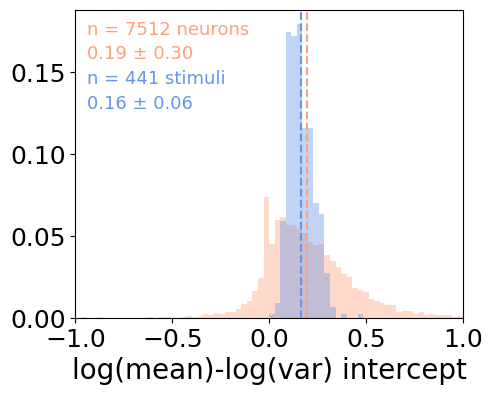

0.16495035937172914
Across stimuli intercept mean 0.19, SEM 0.0035, std 0.30
0.15404666539269435
Across neurons intercept mean 0.16, SEM 0.0031, std 0.06


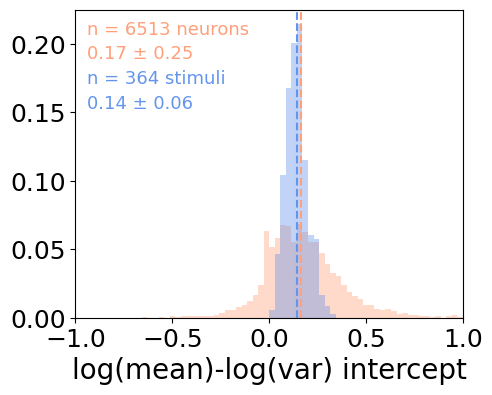

0.15419211258817528
Across stimuli intercept mean 0.17, SEM 0.0031, std 0.25
0.13891565515179444
Across neurons intercept mean 0.14, SEM 0.0029, std 0.06


In [16]:
# intercept across neurons (familiar vs. novel) (active block)

# bool_fam2 = ~bool_sess_excl & bool_fam
# bool_nov2 = ~bool_sess_excl & bool_nov
bool_fam2 = bool_fam
bool_nov2 = bool_nov
list_slopes_all_att_loglog_act_fam = list_slopes_all_att_loglog_act[bool_fam2].copy()
list_slopes_all_att_loglog_act_nov = list_slopes_all_att_loglog_act[bool_nov2].copy()
list_slopes_all_an_loglog_act_fam = list_slopes_all_an_loglog_act[bool_fam2].copy()
list_slopes_all_an_loglog_act_nov = list_slopes_all_an_loglog_act[bool_nov2].copy()

# 1. familiar
fig, ax = plt.subplots(figsize=(5, 4))

list_intcpts_all_att_loglog_act_fam_flattened = np.concatenate([slopes[1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_att_loglog_act_fam) if slopes is not None])
lower_bound, upper_bound = -1, 1
n_bins = 70
weights = np.ones_like(list_intcpts_all_att_loglog_act_fam_flattened)
weights = np.ones_like(list_intcpts_all_att_loglog_act_fam_flattened) / len(list_intcpts_all_att_loglog_act_fam_flattened)
ax.hist(list_intcpts_all_att_loglog_act_fam_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='lightsalmon', alpha=0.4, label='LMLV$_{neuron}$')
ax.axvline(np.nanmean(list_intcpts_all_att_loglog_act_fam_flattened), color='lightsalmon', linestyle='--')

list_intcpts_all_an_loglog_act_fam_flattened = np.concatenate([slopes[1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_act_fam) if slopes is not None])
lower_bound, upper_bound = -1, 1
n_bins = 70
weights = np.ones_like(list_intcpts_all_an_loglog_act_fam_flattened)
weights = np.ones_like(list_intcpts_all_an_loglog_act_fam_flattened) / len(list_intcpts_all_an_loglog_act_fam_flattened)
ax.hist(list_intcpts_all_an_loglog_act_fam_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='cornflowerblue', alpha=0.4, label='LMLV$_{stim}$')
ax.axvline(np.nanmean(list_intcpts_all_an_loglog_act_fam_flattened), color='cornflowerblue', linestyle='--')

# ax.set_title(f'Active familiar', fontsize=20)
ax.set_xlabel('log(mean)-log(var) intercept', fontsize=20)
# ax.set_ylabel('Probability', fontsize=20)
# ax.set_xticks([0, 0.5, 1, 1.5, 2])
# ax.set_yticks([100, 300, 500, 700])
ax.tick_params('both', labelsize=18)

ax.set_xlim(-1, 1)
# ax.set_ylim(0, 0.35)
# ax.legend(loc='upper left', prop={'size': 14})
ax.annotate(f'n = {list_intcpts_all_att_loglog_act_fam_flattened.shape[0]} neurons', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=13, color='lightsalmon')
# ax.annotate(f'{np.nanmean(list_intcpts_all_att_loglog_act_fam_flattened):.3f} ± {sem(list_intcpts_all_att_loglog_act_fam_flattened, nan_policy="omit"):.3f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'{np.nanmean(list_intcpts_all_att_loglog_act_fam_flattened):.2f} ± {np.nanstd(list_intcpts_all_att_loglog_act_fam_flattened, ddof=1):.2f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'n = {list_intcpts_all_an_loglog_act_fam_flattened.shape[0]} stimuli', xy=(0.03, 0.76), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
# ax.annotate(f'{np.mean(list_intcpts_all_an_loglog_act_fam_flattened):.3f} ± {sem(list_intcpts_all_an_loglog_act_fam_flattened):.3f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
ax.annotate(f'{np.mean(list_intcpts_all_an_loglog_act_fam_flattened):.2f} ± {np.std(list_intcpts_all_an_loglog_act_fam_flattened, ddof=1):.2f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')

# plt.savefig('code_images\\svg\\ABCD_intcpt_histogram_actfam_2cond.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\ABCD_intcpt_histogram_actfam_2cond.png', dpi=300, bbox_inches='tight')
plt.show()

# print
print(np.nanmedian(list_intcpts_all_att_loglog_act_fam_flattened))
print(f'Across stimuli intercept mean {np.nanmean(list_intcpts_all_att_loglog_act_fam_flattened):.2f}, SEM {sem(list_intcpts_all_att_loglog_act_fam_flattened, nan_policy="omit"):.4f}, \
std {np.nanstd(list_intcpts_all_att_loglog_act_fam_flattened, ddof=1):.2f}')

print(np.median(list_intcpts_all_an_loglog_act_fam_flattened))
print(f'Across neurons intercept mean {np.nanmean(list_intcpts_all_an_loglog_act_fam_flattened):.2f}, SEM {sem(list_intcpts_all_an_loglog_act_fam_flattened, nan_policy="omit"):.4f}, \
std {np.nanstd(list_intcpts_all_an_loglog_act_fam_flattened, ddof=1):.2f}')

# 2. novel
fig, ax = plt.subplots(figsize=(5, 4))

list_intcpts_all_att_loglog_act_nov_flattened = np.concatenate([slopes[1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_att_loglog_act_nov) if slopes is not None])
lower_bound, upper_bound = -1, 1
n_bins = 70
weights = np.ones_like(list_intcpts_all_att_loglog_act_nov_flattened)
weights = np.ones_like(list_intcpts_all_att_loglog_act_nov_flattened) / len(list_intcpts_all_att_loglog_act_nov_flattened)
ax.hist(list_intcpts_all_att_loglog_act_nov_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='lightsalmon', alpha=0.4, label='neurons')
ax.axvline(np.nanmean(list_intcpts_all_att_loglog_act_nov_flattened), color='lightsalmon', linestyle='--')

list_intcpts_all_an_loglog_act_nov_flattened = np.concatenate([slopes[1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_act_nov) if slopes is not None])
lower_bound, upper_bound = -1, 1
n_bins = 70
weights = np.ones_like(list_intcpts_all_an_loglog_act_nov_flattened)
weights = np.ones_like(list_intcpts_all_an_loglog_act_nov_flattened) / len(list_intcpts_all_an_loglog_act_nov_flattened)
ax.hist(list_intcpts_all_an_loglog_act_nov_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='cornflowerblue', alpha=0.4, label='stimuli')
ax.axvline(np.nanmean(list_intcpts_all_an_loglog_act_nov_flattened), color='cornflowerblue', linestyle='--')

# ax.set_title(f'Active novel', fontsize=20)
ax.set_xlabel('log(mean)-log(var) intercept', fontsize=20)
# ax.set_ylabel('Probability', fontsize=20)
# ax.set_xticks([0, 0.5, 1, 1.5, 2])
# ax.set_yticks([100, 300, 500, 700])
ax.tick_params('both', labelsize=18)

ax.set_xlim(-1, 1)
# ax.set_ylim(0, 0.35)
# ax.legend(loc='upper left', prop={'size': 14})
ax.annotate(f'n = {list_intcpts_all_att_loglog_act_nov_flattened.shape[0]} neurons', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=13, color='lightsalmon')
# ax.annotate(f'{np.nanmean(list_intcpts_all_att_loglog_act_nov_flattened):.3f} ± {sem(list_intcpts_all_att_loglog_act_nov_flattened, nan_policy="omit"):.3f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'{np.nanmean(list_intcpts_all_att_loglog_act_nov_flattened):.2f} ± {np.nanstd(list_intcpts_all_att_loglog_act_nov_flattened, ddof=1):.2f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'n = {list_intcpts_all_an_loglog_act_nov_flattened.shape[0]} stimuli', xy=(0.03, 0.76), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
# ax.annotate(f'{np.mean(list_intcpts_all_an_loglog_act_nov_flattened):.3f} ± {sem(list_intcpts_all_an_loglog_act_nov_flattened):.3f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
ax.annotate(f'{np.mean(list_intcpts_all_an_loglog_act_nov_flattened):.2f} ± {np.std(list_intcpts_all_an_loglog_act_nov_flattened, ddof=1):.2f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')

# plt.savefig('code_images\\svg\\ABCD_intcpt_histogram_actnov_2cond.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\ABCD_intcpt_histogram_actnov_2cond.png', dpi=300, bbox_inches='tight')
plt.show()

# print
print(np.nanmedian(list_intcpts_all_att_loglog_act_nov_flattened))
print(f'Across stimuli intercept mean {np.nanmean(list_intcpts_all_att_loglog_act_nov_flattened):.2f}, SEM {sem(list_intcpts_all_att_loglog_act_nov_flattened, nan_policy="omit"):.4f}, \
std {np.nanstd(list_intcpts_all_att_loglog_act_nov_flattened, ddof=1):.2f}')

print(np.median(list_intcpts_all_an_loglog_act_nov_flattened))
print(f'Across neurons intercept mean {np.nanmean(list_intcpts_all_an_loglog_act_nov_flattened):.2f}, SEM {sem(list_intcpts_all_an_loglog_act_nov_flattened, nan_policy="omit"):.4f}, \
std {np.nanstd(list_intcpts_all_an_loglog_act_nov_flattened, ddof=1):.2f}')

## Figure 1m, n

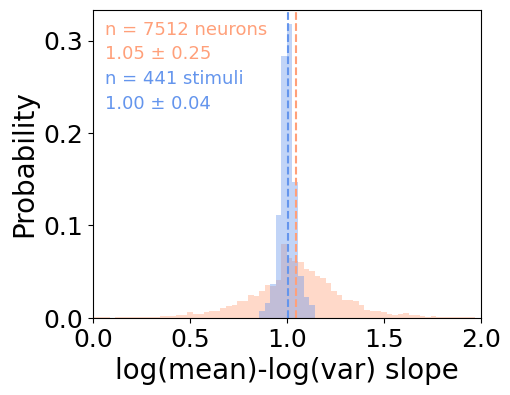

1.0468932337057415
Across stimuli slope mean 1.05, SEM 0.0029, std 0.25
1.004344309933341
Across neurons slope mean 1.00, SEM 0.0019, std 0.04


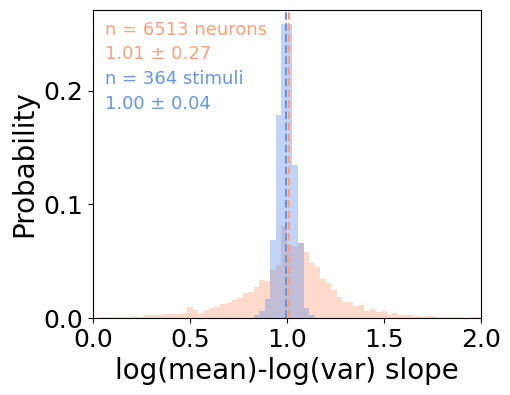

1.024879281921248
Across stimuli slope mean 1.01, SEM 0.0033, std 0.27
0.9971498020924511
Across neurons slope mean 1.00, SEM 0.0021, std 0.04


In [17]:
# slope across neurons vs. across stimuli (familiar vs. novel) (Passive block)

list_slopes_all_att_loglog_pas_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_att_loglog_pas) if sess_ind in np.where(~bool_sess_excl)[0] and slopes is not None])
list_slopes_all_an_loglog_pas_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_pas) if sess_ind in np.where(~bool_sess_excl)[0] and slopes is not None])

# bool_fam2 = ~bool_sess_excl & bool_fam
# bool_nov2 = ~bool_sess_excl & bool_nov
bool_fam2 = bool_fam
bool_nov2 = bool_nov
list_slopes_all_att_loglog_pas_fam = list_slopes_all_att_loglog_pas[bool_fam2].copy()
list_slopes_all_att_loglog_pas_nov = list_slopes_all_att_loglog_pas[bool_nov2].copy()
list_slopes_all_an_loglog_pas_fam = list_slopes_all_an_loglog_pas[bool_fam2].copy()
list_slopes_all_an_loglog_pas_nov = list_slopes_all_an_loglog_pas[bool_nov2].copy()

# 1. familiar
fig, ax = plt.subplots(figsize=(5, 4))

list_slopes_all_att_loglog_pas_fam_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_att_loglog_pas_fam) if slopes is not None])
lower_bound, upper_bound = 0, 2
n_bins = 70
weights = np.ones_like(list_slopes_all_att_loglog_pas_fam_flattened)
weights = np.ones_like(list_slopes_all_att_loglog_pas_fam_flattened) / len(list_slopes_all_att_loglog_pas_fam_flattened)
ax.hist(list_slopes_all_att_loglog_pas_fam_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='lightsalmon', alpha=0.4)
ax.axvline(np.nanmean(list_slopes_all_att_loglog_pas_fam_flattened), color='lightsalmon', linestyle='--')

list_slopes_all_an_loglog_pas_fam_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_pas_fam) if slopes is not None])
lower_bound, upper_bound = 0, 2
n_bins = 70
weights = np.ones_like(list_slopes_all_an_loglog_pas_fam_flattened)
weights = np.ones_like(list_slopes_all_an_loglog_pas_fam_flattened) / len(list_slopes_all_an_loglog_pas_fam_flattened)
ax.hist(list_slopes_all_an_loglog_pas_fam_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='cornflowerblue', alpha=0.4)
ax.axvline(np.nanmean(list_slopes_all_an_loglog_pas_fam_flattened), color='cornflowerblue', linestyle='--')

# ax.set_title(f'Passive familiar', fontsize=20)
ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
ax.set_ylabel('Probability', fontsize=20)
# ax.set_xticks([0, 0.5, 1, 1.5, 2])
# ax.set_yticks([100, 300, 500, 700])
ax.tick_params('both', labelsize=18)

ax.set_xlim(0, 2)
# ax.set_ylim(0, 0.35)
ax.annotate(f'n = {list_slopes_all_att_loglog_pas_fam_flattened.shape[0]} neurons', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=13, color='lightsalmon')
# ax.annotate(f'{np.nanmean(list_slopes_all_att_loglog_pas_fam_flattened):.3f} ± {sem(list_slopes_all_att_loglog_pas_fam_flattened, nan_policy="omit"):.3f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'{np.nanmean(list_slopes_all_att_loglog_pas_fam_flattened):.2f} ± {np.nanstd(list_slopes_all_att_loglog_pas_fam_flattened, ddof=1):.2f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'n = {list_slopes_all_an_loglog_pas_fam_flattened.shape[0]} stimuli', xy=(0.03, 0.76), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
# ax.annotate(f'{np.mean(list_slopes_all_an_loglog_pas_fam_flattened):.3f} ± {sem(list_slopes_all_an_loglog_pas_fam_flattened):.3f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
ax.annotate(f'{np.mean(list_slopes_all_an_loglog_pas_fam_flattened):.2f} ± {np.std(list_slopes_all_an_loglog_pas_fam_flattened, ddof=1):.2f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')

# plt.savefig('code_images\\svg\\ABCD_slope_histogram_pasfam_2cond.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\ABCD_slope_histogram_pasfam_2cond.png', dpi=300, bbox_inches='tight')
plt.show()

# print
print(np.nanmedian(list_slopes_all_att_loglog_pas_fam_flattened))
print(f'Across stimuli slope mean {np.nanmean(list_slopes_all_att_loglog_pas_fam_flattened):.2f}, SEM {sem(list_slopes_all_att_loglog_pas_fam_flattened, nan_policy="omit"):.4f}, \
std {np.nanstd(list_slopes_all_att_loglog_pas_fam_flattened, ddof=1):.2f}')

print(np.median(list_slopes_all_an_loglog_pas_fam_flattened))
print(f'Across neurons slope mean {np.nanmean(list_slopes_all_an_loglog_pas_fam_flattened):.2f}, SEM {sem(list_slopes_all_an_loglog_pas_fam_flattened, nan_policy="omit"):.4f}, \
std {np.nanstd(list_slopes_all_an_loglog_pas_fam_flattened, ddof=1):.2f}')

# 2. novel
fig, ax = plt.subplots(figsize=(5, 4))

list_slopes_all_att_loglog_pas_nov_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_att_loglog_pas_nov) if slopes is not None])
lower_bound, upper_bound = 0, 2
n_bins = 70
weights = np.ones_like(list_slopes_all_att_loglog_pas_nov_flattened)
weights = np.ones_like(list_slopes_all_att_loglog_pas_nov_flattened) / len(list_slopes_all_att_loglog_pas_nov_flattened)
ax.hist(list_slopes_all_att_loglog_pas_nov_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='lightsalmon', alpha=0.4)
ax.axvline(np.nanmean(list_slopes_all_att_loglog_pas_nov_flattened), color='lightsalmon', linestyle='--')

list_slopes_all_an_loglog_pas_nov_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_pas_nov) if slopes is not None])
lower_bound, upper_bound = 0, 2
n_bins = 70
weights = np.ones_like(list_slopes_all_an_loglog_pas_nov_flattened)
weights = np.ones_like(list_slopes_all_an_loglog_pas_nov_flattened) / len(list_slopes_all_an_loglog_pas_nov_flattened)
ax.hist(list_slopes_all_an_loglog_pas_nov_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='cornflowerblue', alpha=0.4)
ax.axvline(np.nanmean(list_slopes_all_an_loglog_pas_nov_flattened), color='cornflowerblue', linestyle='--')

# ax.set_title(f'Passive novel', fontsize=20)
ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
ax.set_ylabel('Probability', fontsize=20)
# ax.set_xticks([0, 0.5, 1, 1.5, 2])
# ax.set_yticks([100, 300, 500, 700])
ax.set_yticks(np.arange(0, 0.21, 0.1))
ax.tick_params('both', labelsize=18)

ax.set_xlim(0, 2)
# ax.set_ylim(0, 0.35)
ax.annotate(f'n = {list_slopes_all_att_loglog_pas_nov_flattened.shape[0]} neurons', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=13, color='lightsalmon')
# ax.annotate(f'{np.nanmean(list_slopes_all_att_loglog_pas_nov_flattened):.3f} ± {sem(list_slopes_all_att_loglog_pas_nov_flattened, nan_policy="omit"):.3f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'{np.nanmean(list_slopes_all_att_loglog_pas_nov_flattened):.2f} ± {np.nanstd(list_slopes_all_att_loglog_pas_nov_flattened, ddof=1):.2f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'n = {list_slopes_all_an_loglog_pas_nov_flattened.shape[0]} stimuli', xy=(0.03, 0.76), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
# ax.annotate(f'{np.mean(list_slopes_all_an_loglog_pas_nov_flattened):.3f} ± {sem(list_slopes_all_an_loglog_pas_nov_flattened):.3f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
ax.annotate(f'{np.mean(list_slopes_all_an_loglog_pas_nov_flattened):.2f} ± {np.std(list_slopes_all_an_loglog_pas_nov_flattened, ddof=1):.2f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')

# plt.savefig('code_images\\svg\\ABCD_slope_histogram_pasnov_2cond.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\ABCD_slope_histogram_pasnov_2cond.png', dpi=300, bbox_inches='tight')
plt.show()

# print
print(np.nanmedian(list_slopes_all_att_loglog_pas_nov_flattened))
print(f'Across stimuli slope mean {np.nanmean(list_slopes_all_att_loglog_pas_nov_flattened):.2f}, SEM {sem(list_slopes_all_att_loglog_pas_nov_flattened, nan_policy="omit"):.4f}, \
std {np.nanstd(list_slopes_all_att_loglog_pas_nov_flattened, ddof=1):.2f}')

print(np.median(list_slopes_all_an_loglog_pas_nov_flattened))
print(f'Across neurons slope mean {np.nanmean(list_slopes_all_an_loglog_pas_nov_flattened):.2f}, SEM {sem(list_slopes_all_an_loglog_pas_nov_flattened, nan_policy="omit"):.4f}, \
std {np.nanstd(list_slopes_all_an_loglog_pas_nov_flattened, ddof=1):.2f}')

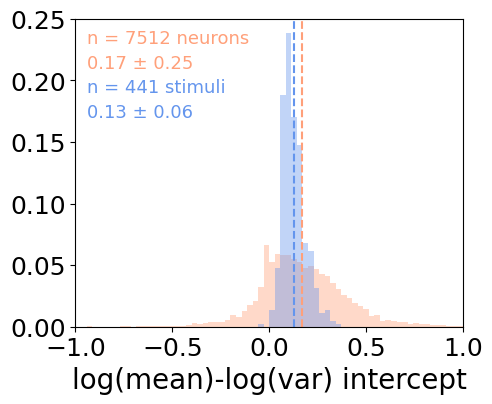

0.14844632078139947
Across stimuli intercept mean 0.17, SEM 0.0029, std 0.25
0.1157109393945898
Across neurons intercept mean 0.13, SEM 0.0028, std 0.06


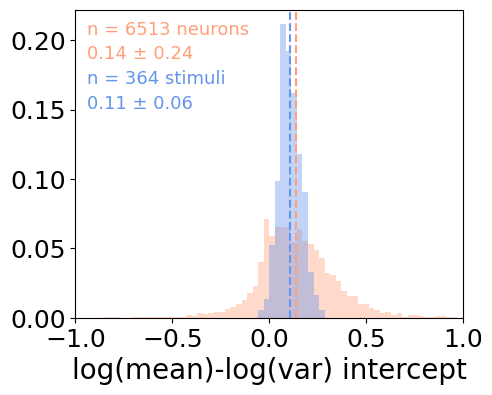

0.12532179333031243
Across stimuli intercept mean 0.14, SEM 0.0029, std 0.24
0.10464038941210065
Across neurons intercept mean 0.11, SEM 0.0029, std 0.06


In [18]:
# intercept across neurons (familiar vs. novel) (passive block)

# bool_fam2 = ~bool_sess_excl & bool_fam
# bool_nov2 = ~bool_sess_excl & bool_nov
bool_fam2 = bool_fam
bool_nov2 = bool_nov
list_slopes_all_att_loglog_pas_fam = list_slopes_all_att_loglog_pas[bool_fam2].copy()
list_slopes_all_att_loglog_pas_nov = list_slopes_all_att_loglog_pas[bool_nov2].copy()
list_slopes_all_an_loglog_pas_fam = list_slopes_all_an_loglog_pas[bool_fam2].copy()
list_slopes_all_an_loglog_pas_nov = list_slopes_all_an_loglog_pas[bool_nov2].copy()

# 1. familiar
fig, ax = plt.subplots(figsize=(5, 4))

list_intcpts_all_att_loglog_pas_fam_flattened = np.concatenate([slopes[1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_att_loglog_pas_fam) if slopes is not None])
lower_bound, upper_bound = -1, 1
n_bins = 70
weights = np.ones_like(list_intcpts_all_att_loglog_pas_fam_flattened)
weights = np.ones_like(list_intcpts_all_att_loglog_pas_fam_flattened) / len(list_intcpts_all_att_loglog_pas_fam_flattened)
ax.hist(list_intcpts_all_att_loglog_pas_fam_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='lightsalmon', alpha=0.4, label='LMLV$_{neuron}$')
ax.axvline(np.nanmean(list_intcpts_all_att_loglog_pas_fam_flattened), color='lightsalmon', linestyle='--')

list_intcpts_all_an_loglog_pas_fam_flattened = np.concatenate([slopes[1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_pas_fam) if slopes is not None])
lower_bound, upper_bound = -1, 1
n_bins = 70
weights = np.ones_like(list_intcpts_all_an_loglog_pas_fam_flattened)
weights = np.ones_like(list_intcpts_all_an_loglog_pas_fam_flattened) / len(list_intcpts_all_an_loglog_pas_fam_flattened)
ax.hist(list_intcpts_all_an_loglog_pas_fam_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='cornflowerblue', alpha=0.4, label='LMLV$_{stim}$')
ax.axvline(np.nanmean(list_intcpts_all_an_loglog_pas_fam_flattened), color='cornflowerblue', linestyle='--')

# ax.set_title(f'Active familiar', fontsize=20)
ax.set_xlabel('log(mean)-log(var) intercept', fontsize=20)
# ax.set_ylabel('Probability', fontsize=20)
# ax.set_xticks([0, 0.5, 1, 1.5, 2])
# ax.set_yticks([100, 300, 500, 700])
ax.tick_params('both', labelsize=18)

ax.set_xlim(-1, 1)
# ax.set_ylim(0, 0.35)
# ax.legend(loc='upper left', prop={'size': 14})
ax.annotate(f'n = {list_intcpts_all_att_loglog_pas_fam_flattened.shape[0]} neurons', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=13, color='lightsalmon')
# ax.annotate(f'{np.nanmean(list_intcpts_all_att_loglog_pas_fam_flattened):.3f} ± {sem(list_intcpts_all_att_loglog_pas_fam_flattened, nan_policy="omit"):.3f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'{np.nanmean(list_intcpts_all_att_loglog_pas_fam_flattened):.2f} ± {np.nanstd(list_intcpts_all_att_loglog_pas_fam_flattened, ddof=1):.2f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'n = {list_intcpts_all_an_loglog_pas_fam_flattened.shape[0]} stimuli', xy=(0.03, 0.76), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
# ax.annotate(f'{np.mean(list_intcpts_all_an_loglog_pas_fam_flattened):.3f} ± {sem(list_intcpts_all_an_loglog_pas_fam_flattened):.3f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
ax.annotate(f'{np.mean(list_intcpts_all_an_loglog_pas_fam_flattened):.2f} ± {np.std(list_intcpts_all_an_loglog_pas_fam_flattened, ddof=1):.2f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')

# plt.savefig('code_images\\svg\\ABCD_intcpt_histogram_pasfam_2cond.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\ABCD_intcpt_histogram_pasfam_2cond.png', dpi=300, bbox_inches='tight')
plt.show()

# print
print(np.nanmedian(list_intcpts_all_att_loglog_pas_fam_flattened))
print(f'Across stimuli intercept mean {np.nanmean(list_intcpts_all_att_loglog_pas_fam_flattened):.2f}, SEM {sem(list_intcpts_all_att_loglog_pas_fam_flattened, nan_policy="omit"):.4f}, \
std {np.nanstd(list_intcpts_all_att_loglog_pas_fam_flattened, ddof=1):.2f}')

print(np.median(list_intcpts_all_an_loglog_pas_fam_flattened))
print(f'Across neurons intercept mean {np.nanmean(list_intcpts_all_an_loglog_pas_fam_flattened):.2f}, SEM {sem(list_intcpts_all_an_loglog_pas_fam_flattened, nan_policy="omit"):.4f}, \
std {np.nanstd(list_intcpts_all_an_loglog_pas_fam_flattened, ddof=1):.2f}')

# 2. novel
fig, ax = plt.subplots(figsize=(5, 4))

list_intcpts_all_att_loglog_pas_nov_flattened = np.concatenate([slopes[1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_att_loglog_pas_nov) if slopes is not None])
lower_bound, upper_bound = -1, 1
n_bins = 70
weights = np.ones_like(list_intcpts_all_att_loglog_pas_nov_flattened)
weights = np.ones_like(list_intcpts_all_att_loglog_pas_nov_flattened) / len(list_intcpts_all_att_loglog_pas_nov_flattened)
ax.hist(list_intcpts_all_att_loglog_pas_nov_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='lightsalmon', alpha=0.4, label='LMLV$_{neuron}$')
ax.axvline(np.nanmean(list_intcpts_all_att_loglog_pas_nov_flattened), color='lightsalmon', linestyle='--')

list_intcpts_all_an_loglog_pas_nov_flattened = np.concatenate([slopes[1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_pas_nov) if slopes is not None])
lower_bound, upper_bound = -1, 1
n_bins = 70
weights = np.ones_like(list_intcpts_all_an_loglog_pas_nov_flattened)
weights = np.ones_like(list_intcpts_all_an_loglog_pas_nov_flattened) / len(list_intcpts_all_an_loglog_pas_nov_flattened)
ax.hist(list_intcpts_all_an_loglog_pas_nov_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='cornflowerblue', alpha=0.4, label='LMLV$_{stim}$')
ax.axvline(np.nanmean(list_intcpts_all_an_loglog_pas_nov_flattened), color='cornflowerblue', linestyle='--')

# ax.set_title(f'Active novel', fontsize=20)
ax.set_xlabel('log(mean)-log(var) intercept', fontsize=20)
# ax.set_ylabel('Probability', fontsize=20)
# ax.set_xticks([0, 0.5, 1, 1.5, 2])
# ax.set_yticks([100, 300, 500, 700])
ax.tick_params('both', labelsize=18)

ax.set_xlim(-1, 1)
# ax.set_ylim(0, 0.35)
# ax.legend(loc='upper left', prop={'size': 14})
ax.annotate(f'n = {list_intcpts_all_att_loglog_pas_nov_flattened.shape[0]} neurons', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=13, color='lightsalmon')
# ax.annotate(f'{np.nanmean(list_intcpts_all_att_loglog_pas_nov_flattened):.3f} ± {sem(list_intcpts_all_att_loglog_pas_nov_flattened, nan_policy="omit"):.3f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'{np.nanmean(list_intcpts_all_att_loglog_pas_nov_flattened):.2f} ± {np.nanstd(list_intcpts_all_att_loglog_pas_nov_flattened, ddof=1):.2f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'n = {list_intcpts_all_an_loglog_pas_nov_flattened.shape[0]} stimuli', xy=(0.03, 0.76), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
# ax.annotate(f'{np.mean(list_intcpts_all_an_loglog_pas_nov_flattened):.3f} ± {sem(list_intcpts_all_an_loglog_pas_nov_flattened):.3f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
ax.annotate(f'{np.mean(list_intcpts_all_an_loglog_pas_nov_flattened):.2f} ± {np.std(list_intcpts_all_an_loglog_pas_nov_flattened, ddof=1):.2f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')

# plt.savefig('code_images\\svg\\ABCD_intcpt_histogram_pasnov_2cond.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\ABCD_intcpt_histogram_pasnov_2cond.png', dpi=300, bbox_inches='tight')
plt.show()

# print
print(np.nanmedian(list_intcpts_all_att_loglog_pas_nov_flattened))
print(f'Across stimuli intercept mean {np.nanmean(list_intcpts_all_att_loglog_pas_nov_flattened):.2f}, SEM {sem(list_intcpts_all_att_loglog_pas_nov_flattened, nan_policy="omit"):.4f}, \
std {np.nanstd(list_intcpts_all_att_loglog_pas_nov_flattened, ddof=1):.2f}')

print(np.median(list_intcpts_all_an_loglog_pas_nov_flattened))
print(f'Across neurons intercept mean {np.nanmean(list_intcpts_all_an_loglog_pas_nov_flattened):.2f}, SEM {sem(list_intcpts_all_an_loglog_pas_nov_flattened, nan_policy="omit"):.4f}, \
std {np.nanstd(list_intcpts_all_an_loglog_pas_nov_flattened, ddof=1):.2f}')

In [19]:
# # with open('resp_matrix_ep_bhv_all_32sess_gpu.pickle', 'rb') as f:
# #     resp_matrix_ep_RS_all = pickle.load(f)

# #     list_rate_all_act = resp_matrix_ep_RS_all['list_rate_all_act'].copy()
# #     list_rate_all_pas = resp_matrix_ep_RS_all['list_rate_all_pas'].copy()
# #     bool_sess_excl = resp_matrix_ep_RS_all['bool_sess_excl'].copy()
# #     bool_fam = resp_matrix_ep_RS_all['bool_fam'].copy()
# #     bool_nov = resp_matrix_ep_RS_all['bool_nov'].copy()
# #     list_sess_ids = resp_matrix_ep_RS_all['list_sess_ids'].copy()
# #     list_neuallloc = resp_matrix_ep_RS_all['list_neuallloc'].copy()
# #     list_sess_visp = resp_matrix_ep_RS_all['list_sess_visp'].copy()

# with open('resp_matrix_ep_bhv_all_32sess_gpu.pickle', 'wb') as f:
#     pickle.dump({'tree_variables': ['list_rate_all_act', 'list_rate_all_pas', 'list_slopes_all_att_loglog_act', 'list_slopes_all_an_loglog_act', 'list_slopes_all_att_loglog_pas', 'list_slopes_all_an_loglog_pas',
#                                     'bool_sess_excl', 'bool_G', 'bool_H', 'bool_fam', 'bool_nov', 'list_sess_ids', 'list_neuallloc', 'list_sess_visp', 'list_mouse_ids', 'list_mouse_inds'],
#                                     'list_rate_all_act': list_rate_all_act, 'list_rate_all_pas': list_rate_all_pas,
#                                     'list_slopes_all_att_loglog_act': list_slopes_all_att_loglog_act, 'list_slopes_all_an_loglog_act': list_slopes_all_an_loglog_act,
#                                     'list_slopes_all_att_loglog_pas': list_slopes_all_att_loglog_pas, 'list_slopes_all_an_loglog_pas': list_slopes_all_an_loglog_pas,
#                                     'bool_sess_excl': bool_sess_excl, 'bool_G': bool_G, 'bool_H': bool_H, 'bool_fam': bool_fam, 'bool_nov': bool_nov, 'list_sess_ids': list_sess_ids, 'list_neuallloc': list_neuallloc,
#                                     'list_sess_visp': list_sess_visp, 'list_mouse_ids': list_mouse_ids, 'list_mouse_inds': list_mouse_inds}, f)